# Neural Networks 2

## Single Neuron (Perceptron)

At the core of all modern neural networks is a single neuron that transforms its inputs to an output using various operators such as sum, product, and some non-linear mappings such as logsig. A single neuron is surprisingly powerful and therefore it makes sense to study it a little bit more.

<div>
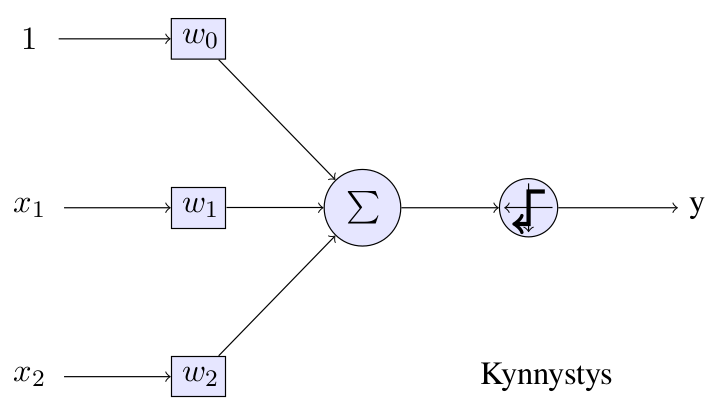
</div>

#### Demo: Implementing logical gates using a single neuron

Import required packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import inv
from scipy.special import expit

print('scipy.special.expit is the logistic sigmoid function')

scipy.special.expit is the logistic sigmoid function


Let's study how the logistic sigmoid behaves, i.e. what kind of values produce binary outputs $y \in 0,1$ suitable for logical gates.

In [ ]:
x = [-10,-2.5,0,2.5,+10]
y = expit(x)

plt.plot(x,y)
#plt.axis([-1.5,1.5,-0.1,1.1])

Plot $x_1 \lor x_2$

In [ ]:
x1 = [0,1,1,0]
x2 = [0,0,1,1]
y  = [0,1,1,1] # x1 OR x2
w1=30
w2=30
w0=-20

plt.plot(x1,x2,'ro')
plt.title('x1 OR x2')
for ind in range(len(y)):
    plt.text(x1[ind],x2[ind],f'y={expit(w1*x1[ind]+w2*x2[ind]+w0):.2f}')

Plot $x_1 \land x_2$

In [ ]:
x1 = [0,1,1,0]
x2 = [0,0,1,1]
y  = [0,0,1,0] # x1 AND x2
w1=15
w2=15
w0=-20

plt.plot(x1,x2,'ro')
plt.title('x1 AND x2')
for ind in range(len(y)):
    plt.text(x1[ind],x2[ind],f'y={expit(w1*x1[ind]+w2*x2[ind]+w0):.2f}')

## Multi-layer Perceptron (MLP)

<div>
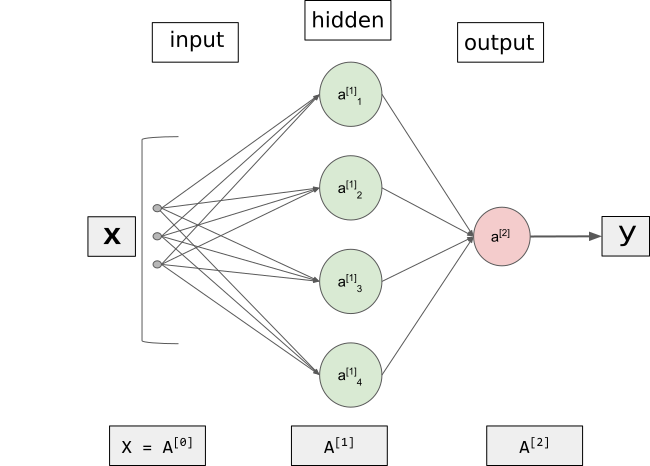
</div>

Plot $x_1 ~XOR~ x_2$

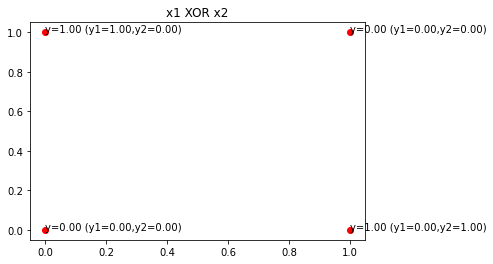

In [2]:
x1 = [0,1,1,0]
x2 = [0,0,1,1]
y  = [0,1,0,1] # x1 XOR x2

w11 = -20
w12 = 30
w10 = -20
w21 = 30
w22 = -20
w20 = -20

w1=30
w2=30
w0=-20

plt.plot(x1,x2,'ro')
plt.title('x1 XOR x2')
for ind in range(len(y)):
    y1 = expit(w11*x1[ind]+w12*x2[ind]+w10)
    y2 = expit(w21*x1[ind]+w22*x2[ind]+w20)
    y  = expit(w1*y1+w2*y2+w0)
    plt.text(x1[ind],x2[ind],f'y={y:.2f} (y1={y1:.2f},y2={y2:.2f})')

#### Demo: GD for XOR-network of three neurons

Note that you might need to run this several times as it often gets stuck into local minima. To improve the performance the data should be properly initialized and the weights should be properly initialized. See:

 * S. Ioffe and C. Szegedy (2015): "Batch Normalization: Accelerating Deep Network Training by Reducing
Internal Covariate Shift" In Proceedings of the International Conference on Machine Learning (ICML) [PDF](http://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43442.pdf)
 * D. Mishin and J. Matas (2016): "All You Need Is a Good Init" In Proceedings of the International Conference on Learning Representations (ICLR) [PDF](http://cmp.felk.cvut.cz/~mishkdmy/papers/mishkin-iclr2016.pdf)

y_1 weights [[-3.11699063]
 [-3.1144432 ]
 [ 6.86502244]]
y_2 weights [[-4.60123501]
 [-4.59149177]
 [-0.27634035]]
y weights [[ 16.57998636]
 [-14.4487273 ]
 [-14.05004795]]
Input x=([0 0]) GT: y(0)=0.00 ; Pred: y_h(0)=0.02
Input x=([1 0]) GT: y(1)=1.00 ; Pred: y_h(1)=0.88
Input x=([1 1]) GT: y(2)=0.00 ; Pred: y_h(2)=0.04
Input x=([0 1]) GT: y(3)=1.00 ; Pred: y_h(3)=0.88


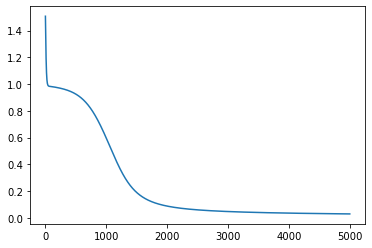

In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Training data is x_1 XOR x_2 function
x = np.array([[0,0],[1,0],[1,1],[0,1]])
y = np.array([[0,1,0,1]]).T

# Initial training parameters w_i^(t)
#w_1_t = [-10,-10,-10] # w1 w2 w0
w_1_t = np.random.normal(0,1,[3,1]) # first hidden
#w_2_t = [100,-100,50] # w1 w2 w0
w_2_t = np.random.normal(0,1,[3,1]) # second hidden
#w_3_t = [-100,100,50] # w1 w2 w0
w_t = np.random.normal(0,1,[3,1]) # output
num_of_epochs = 5000
learning_rate = 0.05

# My logistic sigmoid
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

# Forward pass
def neuron_forward(x1,x2,w1,w2,w0):
    return sigmoid(w1*x1+w2*x2+w0)


MSE = np.zeros([num_of_epochs,1])

# Main training loop
for e in range(num_of_epochs):
    
    # Backward flow and tuning of weights    
    y_hat_sum = 0
    for n in range(x.shape[0]):
        
        x1 = x[n,0]
        x2 = x[n,1]
        y_gt = y[n]
        
        # Forward flows from inputs to outputs
        y_1 = neuron_forward(x1,x2,w_1_t[0],w_1_t[1],w_1_t[2])
        y_2 = neuron_forward(x1,x2,w_2_t[0],w_2_t[1],w_2_t[2])
        y_p = neuron_forward(y_1,y_2,w_t[0],w_t[1],w_t[2])

        # Backward flow and weight updates
        
        # Loss gradient
        sigma_loss = 2*(y_gt-y_p)*-1

        # y weight gradients
        sigma_y_p_w1 = sigma_loss*y_p*(1-y_p)*y_1
        sigma_y_p_w2 = sigma_loss*y_1*(1-y_p)*y_2
        sigma_y_p_w0 = sigma_loss*y_1*(1-y_p)*1
        
        # y update with weight gradients
        w_t[0] = w_t[0] - learning_rate*sigma_y_p_w1
        w_t[1] = w_t[1] - learning_rate*sigma_y_p_w2
        w_t[2] = w_t[2] - learning_rate*sigma_y_p_w0
        
        # y gradient backward flow to its inputs
        sigma_y_p_y_1 = sigma_loss*y_p*(1-y_p)*w_t[0]
        sigma_y_p_y_2 = sigma_loss*y_p*(1-y_p)*w_t[1]

        # y_1 weight gradients
        sigma_y_1_w1 = sigma_y_p_y_1*y_1*(1-y_1)*x1
        sigma_y_1_w2 = sigma_y_p_y_1*y_1*(1-y_1)*x2
        sigma_y_1_w0 = sigma_y_p_y_1*y_1*(1-y_1)*1
        
        # y_1 update with weight gradients
        w_1_t[0] = w_1_t[0] - learning_rate*sigma_y_1_w1
        w_1_t[1] = w_1_t[1] - learning_rate*sigma_y_1_w2
        w_1_t[2] = w_1_t[2] - learning_rate*sigma_y_1_w0

        # y_1 gradient backward flow not needed since there is no more neurons
        
        # y_2 weight gradients
        sigma_y_2_w1 = sigma_y_p_y_2*y_2*(1-y_2)*x1
        sigma_y_2_w2 = sigma_y_p_y_2*y_2*(1-y_2)*x2
        sigma_y_2_w0 = sigma_y_p_y_2*y_2*(1-y_2)*1
        
        # y_2 update with weight gradients
        w_2_t[0] = w_2_t[0] - learning_rate*sigma_y_2_w1
        w_2_t[1] = w_2_t[1] - learning_rate*sigma_y_2_w2
        w_2_t[2] = w_2_t[2] - learning_rate*sigma_y_2_w0

       # y_2 gradient backward flow not needed since there is no more neurons

 
    y_h = np.zeros([x.shape[0],1])
    for n in range(x.shape[0]):
        y_1 = neuron_forward(x[n,0],x[n,1],w_1_t[0],w_1_t[1],w_1_t[2])
        y_2 = neuron_forward(x[n,0],x[n,1],w_2_t[0],w_2_t[1],w_2_t[2])
        y_p = neuron_forward(y_1,y_2,w_t[0],w_t[1],w_t[2])
        y_h[n] = y_p
    MSE[e] = np.sum((y-y_h)**2)

# Final evaluation
print(f'y_1 weights {w_1_t}')
print(f'y_2 weights {w_2_t}')
print(f'y weights {w_t}')
for n in range(x.shape[0]):
    y_1 = neuron_forward(x[n,0],x[n,1],w_1_t[0],w_1_t[1],w_1_t[2])
    y_2 = neuron_forward(x[n,0],x[n,1],w_2_t[0],w_2_t[1],w_2_t[2])
    y_p = neuron_forward(y_1,y_2,w_t[0],w_t[1],w_t[2])
    y_h[n] = y_p
    print(f'Input x=({x[n,:]}) GT: y({n})={y[n,0]:.2f} ; Pred: y_h({n})={y_h[n,0]:.2f}')
plt.plot(range(num_of_epochs),MSE)
plt.show()

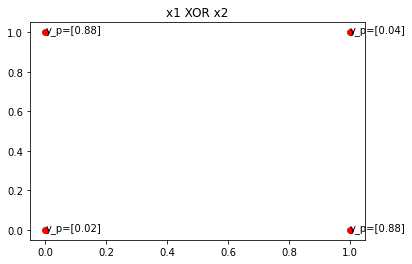

In [7]:
x1 = [0,1,1,0]
x2 = [0,0,1,1]
y  = [0,1,0,1] # x1 XOR x2

plt.plot(x1,x2,'ro')
plt.title('x1 XOR x2')
#w_1_t = w_1_t.astype(float)
#w_2_t = w_2_t.astype(float)
#w_3_t = w_3_t.astype(float)
np.set_printoptions(precision=2)
for ind in range(len(y)):
    y_1 = neuron_forward(x[ind,0],x[ind,1],w_1_t[0],w_1_t[1],w_1_t[2])
    y_2 = neuron_forward(x[ind,0],x[ind,1],w_2_t[0],w_2_t[1],w_2_t[2])
    y_p = neuron_forward(y_1,y_2,w_t[0],w_t[1],w_t[2])
    plt.text(x1[ind],x2[ind],f'y_p={y_p}')
    #plt.text(x1[ind],x2[ind],f'y_p={y_p} (y1={y1},y2={y2})')

For more elegant implementation of a simple neuron and networks working on forward and backward flows can be found from Karpathy's well-known blog post (note that its Python syntax is deprecated):

 * Andrej Karpathy: "Hacker's Guide to Neural Networks" URL: http://karpathy.github.io/neuralnets/

#### Demo: XOR-network using Keras & TensorFlow

## References

C.M. Bishop (2006): Pattern Recognition and Machine Learning, Chapter 5 ([PDF](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)) - Bishop's books are the best to understand neural networks before the deep era.